# FUSION 2026



## Imports

In [1]:
import numpy as np

from datetime import datetime, timedelta
from stonesoup.models.transition.linear import (
    CombinedLinearGaussianTransitionModel,
    ConstantVelocity,
    KnownTurnRate,
)
from stonesoup.types.groundtruth import GroundTruthState, GroundTruthPath

from nereus.platform import TowedArrayPlatform
from nereus.models.environment import Munk, Linear, Constant, FlatBathymetry
from nereus.models.propagation import CylindricalAcousticPropagationModel, rtrsAcousticPropagationModel
from nereus.signal.anthropogenic import BroadbandShipSignal
from nereus.signal.ambient import ColouredNoise
from nereus.simulator import BroadbandPassiveSonarArraySimulator
from nereus.sigproc import DelayAndSumBeamformer, SteeringCalculator, MinimumVarianceDistortionlessResponseBeamformer
from nereus.detector import CFARDetector, PassiveSonarDetector, PeakDetector
from nereus.plotter import BearingsPlotter

seed = 12
np.random.seed(seed)

def random_start_vector(X, Vx, Y, Vy):
    return np.array([
        np.random.uniform(X[0], X[1]),
        np.random.uniform(Vx[0], Vx[1]),
        np.random.uniform(Y[0], Y[1]),
        np.random.uniform(Vy[0], Vy[1]),
        -5,
        0,
    ])

def generate_random_maneuvers(total_duration_s, timestep_s, min_leg_duration_s=60, max_leg_duration_s=300, maneuver_prob=0.5):
    """Generate random sequence of straight/turn maneuvers.
    
    Args:
        total_duration_s: Total simulation time in seconds
        timestep_s: Simulation timestep in seconds
        min_leg_duration_s: Minimum duration for each leg
        max_leg_duration_s: Maximum duration for each leg
        maneuver_prob: Probability of performing a turn maneuver at each leg
    
    Returns:
        maneuver_models: List of transition models (3D)
        maneuver_timesteps: List of timestep indices where transitions occur
        maneuver_descriptions: List of string descriptions for logging
    """
    maneuver_models = []
    maneuver_timesteps = []
    maneuver_descriptions = []
    
    current_time = 0.0
    current_timestep = 0
    
    while current_time < total_duration_s - min_leg_duration_s:
        # Random leg duration (round to nearest timestep)
        leg_duration = np.random.uniform(min_leg_duration_s, max_leg_duration_s)
        leg_duration = round(leg_duration / timestep_s) * timestep_s
        leg_duration = min(leg_duration, total_duration_s - current_time)
        
        # Decide maneuver
        if np.random.rand() > maneuver_prob:
            # Straight leg
            model = CombinedLinearGaussianTransitionModel([
                ConstantVelocity(0.0), 
                ConstantVelocity(0.0), 
                ConstantVelocity(0.0)
            ])
            description = f"Straight ({leg_duration:.0f}s)"
        else:
            # Random turn: -90° to +90° (negative = right turn, positive = left turn)
            turn_angle_deg = np.random.uniform(-90, 90)
            turn_rate_deg_per_s = 1.0  # Standard turn rate
            
            # Calculate actual turn duration based on angle
            turn_duration_s = abs(turn_angle_deg) / turn_rate_deg_per_s
            turn_duration_s = round(turn_duration_s / timestep_s) * timestep_s
            leg_duration = min(turn_duration_s, total_duration_s - current_time)
            
            turn_rate_rad = np.deg2rad(np.sign(turn_angle_deg) * turn_rate_deg_per_s)
            
            turning_2d = KnownTurnRate(
                turn_rate=turn_rate_rad,
                turn_noise_diff_coeffs=np.array([0.0, 0.0])
            )
            
            model = CombinedLinearGaussianTransitionModel([
                turning_2d,
                ConstantVelocity(0.0)  # Constant depth
            ])
            
            direction = "Left" if turn_angle_deg > 0 else "Right"
            description = f"{direction} Turn {abs(turn_angle_deg):.0f}° ({leg_duration:.0f}s)"
        
        maneuver_models.append(model)
        maneuver_timesteps.append(current_timestep)
        maneuver_descriptions.append(description)
        
        current_time += leg_duration
        current_timestep = int(current_time / timestep_s)
    
    return maneuver_models, maneuver_timesteps, maneuver_descriptions


/home/fin/miniconda3/envs/nereus-env/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
/home/fin/miniconda3/envs/nereus-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## sim params

In [2]:
# ============================================================================
# SIMULATION PARAMETERS
# ============================================================================

SIM_LENGTH = 900 # seconds
SIM_RATE = 10.0 # seconds

Xlim = [-15_000, 15_000]
Ylim = [-15_000, 15_000]

NUM_TARGETS = 3

SIM_PARAMS = {
    "start_time":datetime.now().replace(hour=0, minute=0, second=0, microsecond=0),
    "time_interval":timedelta(seconds=SIM_RATE),
    "num_steps":int(SIM_LENGTH / SIM_RATE),
}

total_duration_s = SIM_PARAMS["num_steps"] * SIM_PARAMS["time_interval"].total_seconds()
print(f"Total simulation duration: {total_duration_s} seconds")

SHIP_PARAMS = {
    "start_vector": random_start_vector(Xlim, [-4,4], Ylim, [-4, 4]), 
    "position_mapping": [0, 2, 4],
    "velocity_mapping": [1, 3, 5],
    "transition_model": CombinedLinearGaussianTransitionModel(
        [ConstantVelocity(0), ConstantVelocity(0), ConstantVelocity(0)]
    ),
}

ARRAY_PARAMS = {
    "num_sensors": 100,  
    "tow_cable_length": 100.0,
    "sensor_spacing": 1.0,
    "array_depth": -50.0,
}

TARGETS = []

for i in range(NUM_TARGETS):
    TARGET_PARAMS = {
        "start_vector": random_start_vector(Xlim, [-10.5,10.5], Ylim, [-10.5, 10.5]),  
        "position_mapping": [0, 2, 4],
        "velocity_mapping": [1, 3, 5],
        "transition_model": CombinedLinearGaussianTransitionModel(
            [ConstantVelocity(0), ConstantVelocity(0), ConstantVelocity(0)]
        ),
        "amplitudes_upa": 10 ** (np.random.uniform(87, 102, 4) / 20),
        "frequencies_hz": np.random.uniform(25.0, 200.0, 4),
        "phases_rad": np.random.uniform(0, 2 * np.pi, 4),
        "tonal_bandwidth_hz": np.random.uniform(0.5, 2.0),
        "noise_amplitude_upa":10 ** (np.random.uniform(65, 85) / 20),
        "noise_spectral_exponent":-1.0,
    }
    TARGETS.append(TARGET_PARAMS)

SIGNAL_PARAMS = {
    "duration_s": total_duration_s,
    "sampling_rate_hz": 500.0, 
    "frame_len": 500,
    "hop_factor": 2,
    "fade_in_ms": 1000.0,
}

AMBIENT_NOISE_PARAMS = {
    "amplitude_upa": 10 ** (np.random.uniform(45, 55) / 20),  
    "spectral_exponent": -1,  
}

PROP_PARAMS = {
    # "ssp": Constant(), 
    "ssp": Linear(
        surface_speed=1480.0,
        gradient=0.2
    ),
    "attenuation_factor": 0.5, 
    "bathymetry": FlatBathymetry(depth=-100.0),
}

BF_PARAMS = {
    "shading": None,
    # "shading": "blackman",
    "domain": "frequency",
    "steering_azimuths_rad": np.linspace(-np.pi, np.pi, 181), 
}

# Detection parameters
DET_PARAMS = {
    "cfar_detector": {
        "num_guard_cells": 2,
        "num_training_cells": 5,
        "threshold_factor": 1.05,  
    },
    "peak_detector": {
        "distance": 3,  
    }
}



Total simulation duration: 900.0 seconds


## sim setup

In [3]:
# ============================================================================
# SETUP
# ============================================================================

# Generate random maneuvers for platform
print("Generating random platform maneuvers...")
maneuver_models, maneuver_timesteps, maneuver_descriptions = generate_random_maneuvers(
    total_duration_s=total_duration_s,
    timestep_s=SIM_PARAMS["time_interval"].total_seconds(),
    min_leg_duration_s=60,
    max_leg_duration_s=300,  
    maneuver_prob=0.15
)

# Create platform
print("Creating platform...")
initial_state = GroundTruthState(
    SHIP_PARAMS["start_vector"], timestamp=SIM_PARAMS["start_time"]
)

platform = TowedArrayPlatform(
    states=[initial_state],
    position_mapping=SHIP_PARAMS["position_mapping"],
    velocity_mapping=SHIP_PARAMS["velocity_mapping"],
    transition_model=maneuver_models[0],  # Start with first maneuver
    num_sensors=ARRAY_PARAMS["num_sensors"],
    cable_length_m=ARRAY_PARAMS["tow_cable_length"],
    sensor_spacing_m=ARRAY_PARAMS["sensor_spacing"],
    array_depth_m=ARRAY_PARAMS["array_depth"],
)

# Move platform through all timesteps with maneuver transitions
print("Moving platform through scenario...")
current_maneuver_idx = 0

for i in range(1, SIM_PARAMS["num_steps"]):
    # Check if we need to switch maneuvers
    if current_maneuver_idx < len(maneuver_timesteps) - 1:
        next_maneuver_timestep = maneuver_timesteps[current_maneuver_idx + 1]
        if i >= next_maneuver_timestep:
            current_maneuver_idx += 1
            platform.movement_controller.transition_model = maneuver_models[current_maneuver_idx]
    
    new_time = SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
    platform.move(new_time)

# Create target trajectories
print(f"Creating {NUM_TARGETS} target trajectories with random maneuvers...")
target_ground_truths = []
relative_bearing_ground_truths = []

for target_idx, TARGET_PARAMS in enumerate(TARGETS):

    # Create initial state
    target_states = [
        GroundTruthState(
            TARGET_PARAMS["start_vector"],
            timestamp=SIM_PARAMS["start_time"],
            metadata={
                "amplitudes_upa": TARGET_PARAMS["amplitudes_upa"],
                "frequencies_hz": TARGET_PARAMS["frequencies_hz"],
                "phases_rad": TARGET_PARAMS["phases_rad"],
                "position_mapping": TARGET_PARAMS["position_mapping"],
                "velocity_mapping": TARGET_PARAMS["velocity_mapping"],
                "tonal_bandwidth_hz": TARGET_PARAMS["tonal_bandwidth_hz"],
                "noise_amplitude_upa": TARGET_PARAMS["noise_amplitude_upa"],
                "noise_spectral_exponent": TARGET_PARAMS["noise_spectral_exponent"],
            },
        )
    ]

    # Propagate trajectory with multi-transition models
    current_maneuver_idx = 0
    
    for i in range(1, SIM_PARAMS["num_steps"]):

        transition_model = TARGET_PARAMS["transition_model"]
        new_time = SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
        time_interval = new_time - target_states[-1].timestamp
        new_state_vector = transition_model.function(
            target_states[-1], noise=False, time_interval=time_interval
        )
        new_state = GroundTruthState(
            new_state_vector,
            timestamp=new_time,
            metadata=target_states[-1].metadata,
        )
        target_states.append(new_state)

    target_ground_truth = GroundTruthPath(target_states)
    target_ground_truths.append(target_ground_truth)
    
    # Compute ground truth bearings for plotting
    gt_relative_bearings = []
    for target_state in target_ground_truth.states:
        platform_state = platform.get_platform_state_at(target_state.timestamp)
        ref_sensor_position = np.mean(platform_state.array.state_vector, axis=1)
        target_pos = np.array([target_state.state_vector[0], target_state.state_vector[2]])
        relative_pos = target_pos - ref_sensor_position[:2]
        bearing_rad = np.arctan2(relative_pos[1], relative_pos[0])
        gt_relative_bearings.append(bearing_rad)
    
    gt_relative_bearings = np.array(gt_relative_bearings)
    
    # Create GroundTruthPath for bearings
    relative_bearing_truth_states = []
    for i, bearing in enumerate(gt_relative_bearings):
        timestamp = SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
        bearing_state = GroundTruthState(
            state_vector=np.array([bearing]),
            timestamp=timestamp
        )
        relative_bearing_truth_states.append(bearing_state)
    
    relative_bearing_ground_truth = GroundTruthPath(relative_bearing_truth_states)
    relative_bearing_ground_truths.append(relative_bearing_ground_truth)

# Create signal and propagation models
print("Creating signal and propagation models...")

# prop_model = CylindricalAcousticPropagationModel(
#     ssp=PROP_PARAMS["ssp"],
#     attenuation_factor=PROP_PARAMS["attenuation_factor"],
# )

prop_model = rtrsAcousticPropagationModel(
    ssp=PROP_PARAMS["ssp"],
    bathymetry=PROP_PARAMS["bathymetry"],
    use_all_frequencies=False,  # Will use propagate_spectrum
    step_m=20.0,
    azimuth_search_width=2.0,
    azimuth_resolution=0.5,
    elevation_range=(-25.0, 25.0),
    elevation_resolution=1.0,
)

# Create ambient noise model
ambient_noise_model = ColouredNoise(
    amplitude_upa=AMBIENT_NOISE_PARAMS["amplitude_upa"],
    spectral_exponent=AMBIENT_NOISE_PARAMS["spectral_exponent"],
    duration_s=SIM_PARAMS["time_interval"].total_seconds(),
    sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
)

# Create beamformer and steering calculator
print("Creating beamformer and steering calculator...")
from scipy.signal import get_window

shading = None
if BF_PARAMS["shading"] is not None:
    shading = get_window(BF_PARAMS["shading"], platform.num_sensors)

beamformer = DelayAndSumBeamformer(
    sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
    shading=shading,
    domain=BF_PARAMS["domain"]
)

# beamformer = MinimumVarianceDistortionlessResponseBeamformer(
#     sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
#     fmin=100.0,
#     fmax=125.0,
# )

steering_calculator = SteeringCalculator(
    ssp=PROP_PARAMS["ssp"],
    steering_azimuths_rad=BF_PARAMS["steering_azimuths_rad"],
)

# Create signal models for each target
print("Creating signal models for each target...")
signal_models = []
for target_idx, TARGET_PARAMS in enumerate(TARGETS):
    signal_model = BroadbandShipSignal(
        duration_s=SIGNAL_PARAMS["duration_s"],
        sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
        frame_len=SIGNAL_PARAMS["frame_len"],
        hop_factor=SIGNAL_PARAMS["hop_factor"],
        tonal_bandwidth_hz=TARGET_PARAMS["tonal_bandwidth_hz"],
        noise_amplitude_upa=TARGET_PARAMS["noise_amplitude_upa"],
        noise_spectral_exponent=TARGET_PARAMS["noise_spectral_exponent"],
        noise_freq_range_hz=(0.0, SIGNAL_PARAMS["sampling_rate_hz"]/2),
        tonal_noise_is_constant=True,
        noise_is_constant=True,
    )
    signal_models.append(signal_model)

# Use the first signal model for simplicity (have same time/freq params but different source signal)
signal_model = signal_models[0]

# Create simulator with beamforming
print("Creating broadband simulator with beamforming...")
simulator = BroadbandPassiveSonarArraySimulator(
    platform=platform,
    propagation_model=prop_model,
    signal_model=signal_model,
    noise_model=ambient_noise_model,
    beamformer=beamformer,
    steering_calculator=steering_calculator,
    ground_truth_paths=target_ground_truths,
    fade_in_ms=SIGNAL_PARAMS["fade_in_ms"],
)



Generating random platform maneuvers...
Creating platform...
Moving platform through scenario...
Creating 3 target trajectories with random maneuvers...
Creating signal and propagation models...
Creating beamformer and steering calculator...
Creating signal models for each target...
Creating broadband simulator with beamforming...


## run sim

In [4]:
# ============================================================================
# RUN SIMULATION WITH DETECTION
# ============================================================================

print()
print("Running broadband simulation with beamforming...")
print()

data_generator = simulator.sensor_data_gen()

# Create detection chain
cfar_detector = CFARDetector(
    num_guard_cells=DET_PARAMS["cfar_detector"]["num_guard_cells"],
    num_training_cells=DET_PARAMS["cfar_detector"]["num_training_cells"],
    threshold_factor=DET_PARAMS["cfar_detector"]["threshold_factor"],
)
peak_detector = PeakDetector(distance=DET_PARAMS["peak_detector"]["distance"])

detection_chain = [cfar_detector]
detection_chain.append(peak_detector)

detector = PassiveSonarDetector(
    detection_chain=detection_chain,
    sensor_data_gen=data_generator,
    steering_azimuths_rad=BF_PARAMS["steering_azimuths_rad"]
)

# Run detection
print("Running detection chain...")
all_detections = list(detector.detections_gen())
snr_map = detector.snr_history




Running broadband simulation with beamforming...

Running detection chain...
z range: -50.0 to -5.0
100.0 1500.0
0.0 1480.0
-50.0 1490.0
z range: -50.0 to -5.0
100.0 1500.0
0.0 1480.0
-50.0 1490.0
z range: -50.0 to -5.0
100.0 1500.0
0.0 1480.0
-50.0 1490.0
z range: -50.0 to -5.0
100.0 1500.0
0.0 1480.0
-50.0 1490.0
z range: -50.0 to -5.0
100.0 1500.0
0.0 1480.0
-50.0 1490.0
z range: -50.0 to -5.0
100.0 1500.0
0.0 1480.0
-50.0 1490.0
z range: -50.0 to -5.0
100.0 1500.0
0.0 1480.0
-50.0 1490.0
z range: -50.0 to -5.0
100.0 1500.0
0.0 1480.0
-50.0 1490.0
z range: -50.0 to -5.0
100.0 1500.0
0.0 1480.0
-50.0 1490.0
z range: -50.0 to -5.0
100.0 1500.0
0.0 1480.0
-50.0 1490.0
z range: -50.0 to -5.0
100.0 1500.0
0.0 1480.0
-50.0 1490.0
z range: -50.0 to -5.0
100.0 1500.0
0.0 1480.0
-50.0 1490.0
z range: -50.0 to -5.0
100.0 1500.0
0.0 1480.0
-50.0 1490.0
z range: -50.0 to -5.0
100.0 1500.0
0.0 1480.0
-50.0 1490.0
z range: -50.0 to -5.0
100.0 1500.0
0.0 1480.0
-50.0 1490.0
z range: -50.0 to -5.0

## plots of nereus sim

Generating plots...


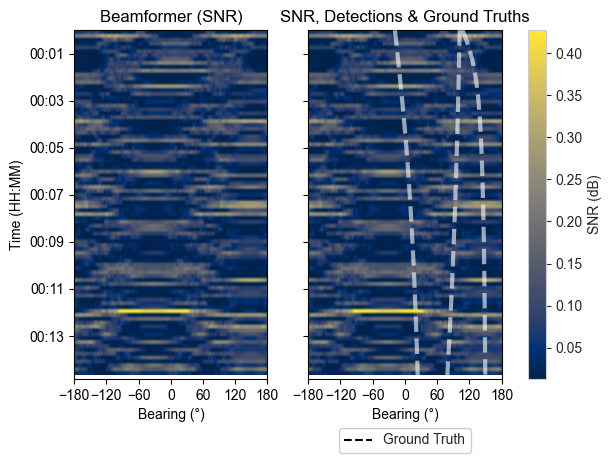

In [5]:
# ============================================================================
# VISUALIZATION
# ============================================================================

print("Generating plots...")

import matplotlib.pyplot as plt

timesteps = [
    SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
    for i in range(SIM_PARAMS["num_steps"])
]

detections_for_plotter = [detection_set for _, detection_set in all_detections]

# Plot 1: Beamformer output with detections
fig1, axs = plt.subplots(1, 2, sharey=True, tight_layout=True)

style_guide = {
    "figure": {
        "figsize": (4, 4),
        "font_size": 10
    }
}
plotter = BearingsPlotter(style_guide=style_guide, bearing_range_deg=(-180, 180))

# Left: Raw SNR (exclude last timestep)
plotter.plot_snr(
    snr_array=snr_map[:-1],
    timesteps=timesteps[:-1],
    all_detections=[],
    truths=[],
    ax=axs[0],
    add_colorbar=False
)
axs[0].set_title("Beamformer (SNR)")

# Right: SNR with detections and truth (exclude last timestep)
_, im = plotter.plot_snr(
    snr_array=snr_map[:-1],
    timesteps=timesteps[:-1],
    all_detections=detections_for_plotter[:-1],
    truths=relative_bearing_ground_truths,
    ax=axs[1],
    add_colorbar=False
)
axs[1].set_ylabel("")
axs[1].set_title(f"SNR, Detections & Ground Truths")

# Add shared colorbar
fig1.colorbar(im, ax=axs.tolist(), label='SNR (dB)')

# plt.suptitle(
#     f"Random Scenario: {NUM_TARGETS} Targets, {ARRAY_PARAMS['num_sensors']} Sensors",
#     fontsize=14,
#     fontweight="bold",
#     y=1.02
# )
plt.savefig("figs/beamformer_detections.png", dpi=300)


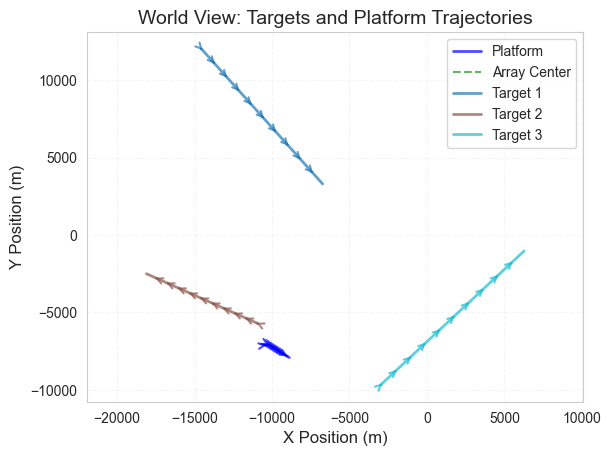

In [ ]:
# Plot 2: Trajectories in Cartesian space
fig2, ax_path = plt.subplots()

# Extract platform positions
platform_x = []
platform_y = []
array_x = []
array_y = []

for timestamp in timesteps:
    platform_state = platform.get_platform_state_at(timestamp)
    platform_x.append(platform_state.host.state.state_vector[0])
    platform_y.append(platform_state.host.state.state_vector[2])
    
    array_center = np.mean(platform_state.array.state_vector, axis=1)
    array_x.append(array_center[0])
    array_y.append(array_center[1])

# Plot platform trajectory with direction arrows
ax_path.plot(platform_x, platform_y, 'b-', label='Platform', linewidth=2, alpha=0.7)
ax_path.plot(array_x, array_y, 'g--', label='Array Center', linewidth=1.5, alpha=0.6)

# Add direction arrows for platform (every 10th point to avoid clutter)
arrow_interval = max(1, len(platform_x) // 10)
for i in range(0, len(platform_x) - 1, arrow_interval):
    dx = platform_x[i + 1] - platform_x[i]
    dy = platform_y[i + 1] - platform_y[i]
    ax_path.annotate('', xy=(platform_x[i + 1], platform_y[i + 1]), 
                    xytext=(platform_x[i], platform_y[i]),
                    arrowprops=dict(arrowstyle='->', color='blue', lw=1.5, alpha=0.7))

# Plot target trajectories with different colors
colors = plt.cm.tab10(np.linspace(0, 1, NUM_TARGETS))

for target_idx, target_ground_truth in enumerate(target_ground_truths):
    target_x = [state.state_vector[0] for state in target_ground_truth]
    target_y = [state.state_vector[2] for state in target_ground_truth]
    
    color = colors[target_idx]
    ax_path.plot(target_x, target_y, '-', color=color, 
                label=f'Target {target_idx + 1}', linewidth=2, alpha=0.7)
    
    # Add direction arrows for each target (every 10th point)
    for i in range(0, len(target_x) - 1, arrow_interval):
        dx = target_x[i + 1] - target_x[i]
        dy = target_y[i + 1] - target_y[i]
        ax_path.annotate('', xy=(target_x[i + 1], target_y[i + 1]), 
                        xytext=(target_x[i], target_y[i]),
                        arrowprops=dict(arrowstyle='->', color=color, lw=1.5, alpha=0.7))

ax_path.set_xlabel('X Position (m)', fontsize=12)
ax_path.set_ylabel('Y Position (m)', fontsize=12)
ax_path.set_title(f'World Picture: Targets and Platform Trajectories', fontsize=14)
ax_path.legend(loc='best', fontsize=10)
ax_path.grid(True, alpha=0.3)
ax_path.axis('equal')

plt.savefig("figs/world_view.png", dpi=300)



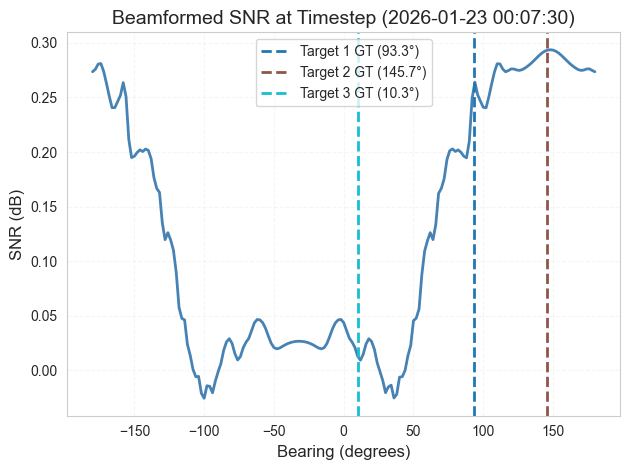

In [7]:
# Plot 3: Beamformed SNR at middle timestep
fig3, ax_middle = plt.subplots()

middle_timestep_idx = SIM_PARAMS["num_steps"] // 2
middle_snr = snr_map[middle_timestep_idx, :]
middle_time = timesteps[middle_timestep_idx]

steering_azimuths_deg = np.rad2deg(BF_PARAMS["steering_azimuths_rad"])
ax_middle.plot(steering_azimuths_deg, middle_snr, linewidth=2, color='steelblue')
ax_middle.set_xlabel('Bearing (degrees)', fontsize=12)
ax_middle.set_ylabel('SNR (dB)', fontsize=12)
ax_middle.set_title(f'Beamformed SNR at Timestep ({middle_time})', fontsize=14)
ax_middle.grid(True, alpha=0.3)

# Mark ground truth bearings for all targets
for target_idx, gt_relative_bearings in enumerate([
    [state.state_vector[0] for state in gt_path.states] 
    for gt_path in relative_bearing_ground_truths
]):
    gt_bearing_deg = np.rad2deg(gt_relative_bearings[middle_timestep_idx])
    color = colors[target_idx]
    ax_middle.axvline(gt_bearing_deg, color=color, linestyle='--', linewidth=2, 
                     label=f'Target {target_idx + 1} GT ({gt_bearing_deg:.1f}°)')

# Mark detections at this timestep if any
if len(detections_for_plotter[middle_timestep_idx]) > 0:
    for det_idx, det in enumerate(detections_for_plotter[middle_timestep_idx]):
        det_bearing_deg = np.rad2deg(det.state_vector[0])
        label = 'Detections' if det_idx == 0 else None
        ax_middle.axvline(det_bearing_deg, color='green', linestyle=':', linewidth=1.5, 
                        label=label, alpha=0.7)

ax_middle.legend(fontsize=10)
plt.tight_layout()

plt.savefig("figs/beamformed_snr_slice.png", dpi=300)

In [8]:
print()
print("=" * 80)
print("Random Scenario Summary:")
print("=" * 80)
print(f"  Seed: {seed}")
print(f"  Number of Targets: {NUM_TARGETS}")
print(f"  Simulation Duration: {total_duration_s} s across {SIM_PARAMS['num_steps']} timesteps")
print(f"  Timestep Interval: {SIM_PARAMS['time_interval'].total_seconds()} s")
print(f"  Array: {ARRAY_PARAMS['num_sensors']} sensors, {ARRAY_PARAMS['sensor_spacing']} m spacing")
print(f"  Signal Sampling Rate: {SIGNAL_PARAMS['sampling_rate_hz']} Hz")
print(f"  Ambient Noise Level: {20 * np.log10(AMBIENT_NOISE_PARAMS['amplitude_upa']):.1f} dB re 1 µPa")
print(f"  Steering Directions: {len(BF_PARAMS['steering_azimuths_rad'])}")
print()
print("  Platform Initial State:")
print(f"    Position: ({SHIP_PARAMS['start_vector'][0]:.0f}, {SHIP_PARAMS['start_vector'][2]:.0f}) m")
print(f"    Velocity: ({SHIP_PARAMS['start_vector'][1]:.1f}, {SHIP_PARAMS['start_vector'][3]:.1f}) m/s")
print()
print(f"  Platform Maneuvers ({len(maneuver_models)} total):")
for i, desc in enumerate(maneuver_descriptions):
    print(f"    {i+1}. {desc} @ timestep {maneuver_timesteps[i]}")
print()
for target_idx, TARGET_PARAMS in enumerate(TARGETS):
    print(f"  Target {target_idx + 1}:")
    print(f"    Frequencies: {TARGET_PARAMS['frequencies_hz']} Hz")
    print(f"    Amplitudes: {20 * np.log10(TARGET_PARAMS['amplitudes_upa'])} dB re 1 µPa")
    print(f"    Start Position: ({TARGET_PARAMS['start_vector'][0]:.0f}, {TARGET_PARAMS['start_vector'][2]:.0f}) m")
    print(f"    Velocity: ({TARGET_PARAMS['start_vector'][1]:.1f}, {TARGET_PARAMS['start_vector'][3]:.1f}) m/s")

plt.show()




Random Scenario Summary:
  Seed: 12
  Number of Targets: 3
  Simulation Duration: 900.0 s across 90 timesteps
  Timestep Interval: 10.0 s
  Array: 100 sensors, 1.0 m spacing
  Signal Sampling Rate: 500.0 Hz
  Ambient Noise Level: 49.2 dB re 1 µPa
  Steering Directions: 181

  Platform Initial State:
    Position: (-10375, -7101) m
    Velocity: (1.9, 0.3) m/s

  Platform Maneuvers (6 total):
    1. Straight (70s) @ timestep 0
    2. Right Turn 40° (40s) @ timestep 7
    3. Straight (210s) @ timestep 11
    4. Straight (180s) @ timestep 32
    5. Straight (270s) @ timestep 50
    6. Straight (130s) @ timestep 77

  Target 1:
    Frequencies: [190.23939881 174.22871969  25.39536587 116.21455476] Hz
    Amplitudes: [101.35424004  89.05813982  91.25742529  96.09124777] dB re 1 µPa
    Start Position: (-14563, 12021) m
    Velocity: (8.8, -9.8) m/s
  Target 2:
    Frequencies: [147.95891217  82.32465835  83.56331759 196.16016383] Hz
    Amplitudes: [94.06844667 99.24252447 91.34380175 97.9

# Target Tracking

simple 

Tracking complete for 0 tracks


<Axes: xlabel='Bearing (°)', ylabel='Time (HH:MM)'>

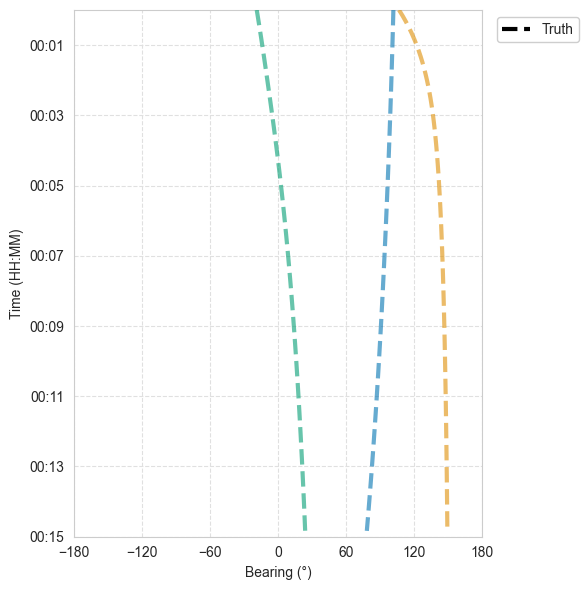

In [9]:
from stonesoup.dataassociator.probability import JPDA
from stonesoup.functions import (
    gm_reduce_single,  # For merging states to get posterior estimate
)
from stonesoup.hypothesiser.probability import PDAHypothesiser

# initiator & deleter components
from stonesoup.hypothesiser.distance import DistanceHypothesiser
from stonesoup.measures import Mahalanobis
from stonesoup.dataassociator.neighbour import GNNWith2DAssignment
from stonesoup.deleter.error import CovarianceBasedDeleter
from stonesoup.initiator.simple import MultiMeasurementInitiator

from stonesoup.models.measurement.linear import LinearGaussian
from stonesoup.models.transition.linear import ConstantVelocity
from stonesoup.predictor.kalman import KalmanPredictor
from stonesoup.types.array import StateVectors
from stonesoup.types.state import GaussianState
from stonesoup.types.track import Track
from stonesoup.types.update import GaussianStateUpdate  # To store posterior estimate
from stonesoup.updater.kalman import ExtendedKalmanUpdater

from stonesoup.types.angle import Bearing

# 1. Transition Model and Predictor
transition_model = ConstantVelocity(0.000001)
predictor = KalmanPredictor(transition_model)

# 2. Measurement Model and Updater
measurement_model = LinearGaussian(
    ndim_state=2,
    mapping=[0],
    noise_covar=np.array([[np.deg2rad(1)**2]])
)
updater = ExtendedKalmanUpdater(measurement_model=measurement_model)

# 3. Hypothesiser and Data Associator
# hypothesiser = PDAHypothesiser(
#     predictor=predictor,
#     updater=updater,
#     clutter_spatial_density=5/np.pi, # 3 false alarms in 180 degrees field
#     prob_detect=0.95
# )
# data_associator = JPDA(hypothesiser=hypothesiser)
hypothesiser = DistanceHypothesiser(predictor, updater, measure=Mahalanobis(), missed_distance=2)
data_associator = GNNWith2DAssignment(hypothesiser)

# deleter
deleter = CovarianceBasedDeleter(covar_trace_thresh=2)

# initiator
relative_bearing_ground_truth = relative_bearing_ground_truths[0]
initial_bearing = relative_bearing_ground_truth[0].state_vector[0] 
initial_bearing += np.random.normal(0, np.deg2rad(2))
initial_state_vector = np.array([initial_bearing, 0])  # Assume initial bearing rate is 0
prior_state = GaussianState(
        initial_state_vector,
        np.diag([np.deg2rad(5)**2, np.deg2rad(0.5)**2]),
        timestamp=SIM_PARAMS["start_time"]
    )

prior_state.state_vector[0,0] = Bearing(prior_state.state_vector[0,0])

initiator = MultiMeasurementInitiator(
    prior_state=prior_state,
    measurement_model=measurement_model,
    deleter=deleter,
    data_associator=data_associator,
    updater=updater,
    min_points=2,
    )

# # 4. Create Initial Tracks for All Targets
# tracks = []
# for target_idx, relative_bearing_ground_truth in enumerate(relative_bearing_ground_truths):
#     # Get the initial ground truth bearing and add some noise
#     initial_bearing = relative_bearing_ground_truth[0].state_vector[0] + \
#         np.random.normal(0, np.deg2rad(2))
#     initial_state_vector = np.array([initial_bearing, 0])  # Assume initial bearing rate is 0

#     # Define initial state with uncertainty
#     prior_state = GaussianState(
#         initial_state_vector,
#         np.diag([np.deg2rad(5)**2, np.deg2rad(0.5)**2]),
#         timestamp=SIM_PARAMS["start_time"]
#     )

#     # Create a track object
#     track = Track([prior_state])
#     tracks.append(track)

# print(f"Initialized {len(tracks)} tracks")

tracks, all_tracks = set(), set()

# 5. Run Tracker for All Targets
for timestamp, detections in all_detections:

    hypotheses = data_associator.associate(
        set(tracks),
        detections,
        timestamp
    )

    associated_detections = set()
    for track in tracks:
        hypothesis = hypotheses[track]
        
        if hypothesis.measurement:
            post = updater.update(hypothesis)
            track.append(post)
            associated_detections.add(hypothesis.measurement)
        else: 
            track.append(hypothesis.prediction)

    # Carry out deletion and initiation
    tracks -= deleter.delete_tracks(tracks)
    tracks |= initiator.initiate(detections - associated_detections, timestamp)
    all_tracks |= tracks

    # for track in tracks:
    #     track_hypotheses = hypotheses[track]

    #     posterior_states = []
    #     posterior_state_weights = []
    #     for hypothesis in track_hypotheses:
    #         if not hypothesis:
    #             posterior_states.append(hypothesis.prediction)
    #         else:
    #             posterior_state = updater.update(hypothesis)
    #             posterior_states.append(posterior_state)
    #         posterior_state_weights.append(hypothesis.probability)

    #     means = StateVectors([state.state_vector for state in posterior_states])
    #     covars = np.stack([state.covar for state in posterior_states], axis=2)
    #     weights = np.asarray(posterior_state_weights)

    #     # Reduce mixture of states to one posterior Gaussian estimate
    #     post_mean, post_covar = gm_reduce_single(means, covars, weights)

    #     # Add a Gaussian state approximation to the track
    #     track.append(
    #         GaussianStateUpdate(
    #             post_mean, post_covar,
    #             track_hypotheses,
    #             track_hypotheses[0].measurement.timestamp
    #         )
    #     )

print(f"Tracking complete for {len(tracks)} tracks")

style_guide = {
    "figure": {
        "figsize": (6, 6),
        "font_size": 10
    }
}
plotter = BearingsPlotter(style_guide=style_guide, bearing_range_deg=(-180, 180))

plotter.plot(
    truths=relative_bearing_ground_truths,
    tracks=tracks,
    all_detections=detections_for_plotter,
    timesteps=timesteps,
    mapping=[0],
    plot_uncertainty=True
)


## full tracker

In [10]:
import numpy as np

from stonesoup.dataassociator.probability import JPDA
from stonesoup.functions import gm_reduce_single
from stonesoup.hypothesiser.probability import PDAHypothesiser

from stonesoup.hypothesiser.distance import DistanceHypothesiser
from stonesoup.dataassociator.neighbour import GNNWith2DAssignment
from stonesoup.measures import Mahalanobis

from stonesoup.deleter.error import CovarianceBasedDeleter
from stonesoup.initiator.simple import MultiMeasurementInitiator

from stonesoup.models.measurement.linear import LinearGaussian
from stonesoup.models.transition.linear import ConstantVelocity
from stonesoup.predictor.kalman import KalmanPredictor
from stonesoup.types.array import StateVectors
from stonesoup.types.state import GaussianState
from stonesoup.types.update import GaussianStateUpdate
from stonesoup.updater.kalman import ExtendedKalmanUpdater
from stonesoup.types.detection import MissedDetection


def wrap_to_pi(angle_rad: float) -> float:
    return (angle_rad + np.pi) % (2 * np.pi) - np.pi

def wrap_state_bearing(state):
    """In-place wrap of bearing component (index 0) on a Stone Soup State/Update."""
    # state_vector is (ndim, 1) StateVector type; be careful with indexing
    state.state_vector[0, 0] = wrap_to_pi(float(state.state_vector[0, 0]))
    return state


def _extract_bearing(measurement) -> float:
    """
    Robustly extract 1D bearing (radians) from a Stone Soup measurement/detection.

    Tries common attributes used across Stone Soup types.
    """
    # Most Stone Soup detection types have state_vector, but some wrappers may not.
    for attr in ("state_vector", "measurement_vector", "vector"):
        v = getattr(measurement, attr, None)
        if v is None:
            continue
        # v might be shape (1,1) or (1,)
        try:
            return float(v[0, 0])
        except Exception:
            return float(v[0])

    # As a last resort, some objects may store a nested state
    state = getattr(measurement, "state", None)
    if state is not None:
        v = getattr(state, "state_vector", None)
        if v is not None:
            try:
                return float(v[0, 0])
            except Exception:
                return float(v[0])

    raise TypeError(
        f"Cannot extract bearing from measurement of type {type(measurement)}; "
        f"no usable vector attribute found."
    )


class WrappedBearingUpdater(ExtendedKalmanUpdater):
    """
    Linear-Gaussian update for 2D state [bearing, bearing_rate] with 1D bearing measurement,
    using wrapped innovation. Avoids mutating measurement objects.

    Works with:
      - SingleHypothesis (normal update)
      - MultipleHypothesis (selects max-prob component if passed accidentally)
    """

    def _as_single_hypothesis(self, hypothesis):
        # MultipleHypothesis is iterable and typically lacks .measurement
        if hasattr(hypothesis, "__iter__") and not hasattr(hypothesis, "measurement"):
            return max(hypothesis, key=lambda h: float(getattr(h, "probability", 0.0)))
        return hypothesis

    def update(self, hypothesis, **kwargs):
        hypothesis = self._as_single_hypothesis(hypothesis)

        # Missed detection hypothesis: measurement can be None or MissedDetection
        if (hypothesis.measurement is None) or isinstance(hypothesis.measurement, MissedDetection):
            return hypothesis.prediction

        pred = hypothesis.prediction
        meas = hypothesis.measurement

        # Predicted state mean/covar
        x = np.array(pred.state_vector, dtype=float)  # (2,1)
        P = np.array(pred.covar, dtype=float)         # (2,2)

        # Measurement: z = bearing
        z = _extract_bearing(meas)                    # scalar
        z_hat = float(x[0, 0])                        # predicted bearing

        # Wrapped innovation nu = wrap(z - z_hat)
        nu = wrap_to_pi(z - z_hat)

        # Linear measurement model: H = [1, 0]
        # R from measurement model
        R = float(self.measurement_model.noise_covar[0, 0])

        # Innovation covariance S = HPH^T + R = P00 + R
        S = float(P[0, 0] + R)
        if S <= 0:
            raise ValueError(f"Innovation covariance S must be > 0, got {S}")

        # Kalman gain K = P H^T S^-1 = P[:,0] / S
        K = (P[:, [0]]) / S   # (2,1)

        # Posterior mean: x_post = x + K * nu
        x_post = x + K * nu

        # Wrap posterior bearing
        x_post[0, 0] = wrap_to_pi(float(x_post[0, 0]))

        # Posterior covariance (Joseph form is numerically safer)
        H = np.array([[1.0, 0.0]])          # (1,2)
        I = np.eye(2)
        P_post = (I - K @ H) @ P @ (I - K @ H).T + K * R * K.T

        # Return an update state (preserve hypothesis/timestamp)
        return GaussianStateUpdate(
            x_post,
            P_post,
            hypothesis,
            meas.timestamp
        )

# STONER SOUP MOD BEARING STONE SOUP.FUNCTIONS 


Tracking complete for 0 active tracks (all_tracks=0)
Tracking complete for 0 tracks


<Axes: xlabel='Bearing (°)', ylabel='Time (HH:MM)'>

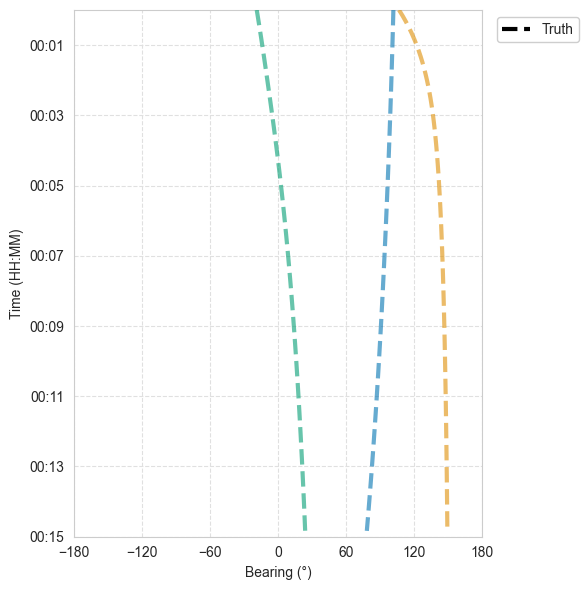

In [11]:
# ============================================================================
# Models
# ============================================================================
transition_model = ConstantVelocity(0.000001)
predictor = KalmanPredictor(transition_model)

measurement_model = LinearGaussian(
    ndim_state=2,
    mapping=[0],
    noise_covar=np.array([[np.deg2rad(1)**2]])
)
updater = WrappedBearingUpdater(measurement_model=measurement_model)

# ============================================================================
# JPDA for main tracking
# ============================================================================
FOV_RAD = np.deg2rad(180)
expected_false_alarms_per_scan = 3
clutter_spatial_density = expected_false_alarms_per_scan / FOV_RAD

jpda_hypothesiser = PDAHypothesiser(
    predictor=predictor,
    updater=updater,
    clutter_spatial_density=clutter_spatial_density,
    prob_detect=0.95
)
jpda_associator = JPDA(hypothesiser=jpda_hypothesiser)

# ============================================================================
# GNN for initiation (single-hypothesis, avoids MultipleHypothesis issue)
# ============================================================================
init_hypothesiser = DistanceHypothesiser(
    predictor=predictor,
    updater=updater,
    measure=Mahalanobis(),
    missed_distance=3.0
)
init_associator = GNNWith2DAssignment(init_hypothesiser)

# ============================================================================
# Track management
# ============================================================================
deleter = CovarianceBasedDeleter(covar_trace_thresh=0.3)

relative_bearing_ground_truth = relative_bearing_ground_truths[0]
initial_bearing = float(relative_bearing_ground_truth[0].state_vector[0]) + np.random.normal(0, np.deg2rad(2))
initial_bearing = wrap_to_pi(initial_bearing)

prior_state = GaussianState(
    np.array([[initial_bearing], [0.0]]),
    np.diag([np.deg2rad(5)**2, np.deg2rad(0.5)**2]),
    timestamp=SIM_PARAMS["start_time"]
)
wrap_state_bearing(prior_state)

initiator = MultiMeasurementInitiator(
    prior_state=prior_state,
    measurement_model=measurement_model,
    deleter=deleter,
    data_associator=init_associator, 
    updater=updater,
    min_points=2,
)

tracks, all_tracks = set(), set()

# ============================================================================
# Main loop
# ============================================================================
for timestamp, detections in all_detections:

    # Wrap detections
    for det in detections:
        det.state_vector[0, 0] = wrap_to_pi(float(det.state_vector[0, 0]))

    # JPDA association for existing tracks
    associations = jpda_associator.associate(set(tracks), detections, timestamp)

    associated_detections = set()

    for track in list(tracks):
        track_hypotheses = associations[track]  # MultipleHypothesis

        posterior_states = []
        posterior_weights = []

        for hyp in track_hypotheses:
            if (hyp.measurement is None) or isinstance(hyp.measurement, MissedDetection):
                state = hyp.prediction
                wrap_state_bearing(state)
            else:
                state = updater.update(hyp)
                wrap_state_bearing(state)
                associated_detections.add(hyp.measurement)

            posterior_states.append(state)
            posterior_weights.append(float(hyp.probability))

        means = StateVectors([s.state_vector for s in posterior_states])
        covars = np.stack([s.covar for s in posterior_states], axis=2)
        weights = np.asarray(posterior_weights, dtype=float)
        if weights.sum() > 0:
            weights /= weights.sum()

        post_mean, post_covar = gm_reduce_single(means, covars, weights)
        post_mean = post_mean.copy()
        post_mean[0, 0] = wrap_to_pi(float(post_mean[0, 0]))

        track.append(GaussianStateUpdate(post_mean, post_covar, track_hypotheses, timestamp))

    # Delete and initiate (initiation uses GNN associator)
    tracks -= deleter.delete_tracks(tracks)
    tracks |= initiator.initiate(detections - associated_detections, timestamp)
    all_tracks |= tracks

print(f"Tracking complete for {len(tracks)} active tracks (all_tracks={len(all_tracks)})")


print(f"Tracking complete for {len(tracks)} tracks")

style_guide = {
    "figure": {
        "figsize": (6, 6),
        "font_size": 10
    }
}
plotter = BearingsPlotter(style_guide=style_guide, bearing_range_deg=(-180, 180))

plotter.plot(
    truths=relative_bearing_ground_truths,
    tracks=tracks,
    all_detections=detections_for_plotter,
    timesteps=timesteps,
    mapping=[0],
    plot_uncertainty=True
)

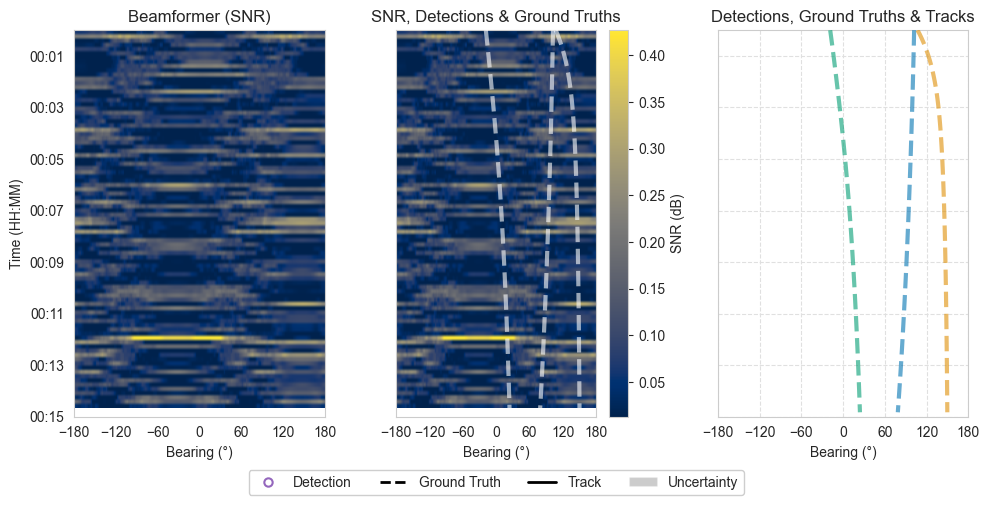

In [12]:
# Beamformer output with detections and tracks
fig1, axs = plt.subplots(1, 3, figsize=(10, 4.8), sharey=True, tight_layout=True)

style_guide = {
    "figure": {
        "figsize": (3, 4),
        "font_size": 10
    },
    "legend": {
        "display": False,  # Disable legend on RHS plot
    },
}
plotter = BearingsPlotter(style_guide=style_guide, bearing_range_deg=(-180, 180))

# Left: Raw SNR (exclude last timestep)
plotter.plot_snr(
    snr_array=snr_map[:-1],
    timesteps=timesteps[:-1],
    all_detections=[],
    truths=[],
    ax=axs[0],
    add_colorbar=False,
    add_legend=False
)
axs[0].set_title("Beamformer (SNR)")

# Middle: SNR with detections and truth (exclude last timestep)
_, im = plotter.plot_snr(
    snr_array=snr_map[:-1],
    timesteps=timesteps[:-1],
    all_detections=detections_for_plotter[:-1],
    truths=relative_bearing_ground_truths,
    ax=axs[1],
    add_colorbar=True,
    add_legend=False
)
axs[1].set_ylabel("")
axs[1].set_title(f"SNR, Detections & Ground Truths")

# Right: Detections, Ground Truths & Tracks (no legend)
plotter.plot(
    truths=relative_bearing_ground_truths,
    tracks=tracks,
    all_detections=detections_for_plotter,
    timesteps=timesteps,
    mapping=[0],
    ax=axs[2],
    plot_uncertainty=True
)
axs[2].set_ylabel("")
axs[2].set_title(f"Detections, Ground Truths & Tracks")

# Create unified legend under middle plot
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='none', 
           markeredgecolor='#9467bd', markersize=6, markeredgewidth=1.5, 
           label='Detection', linestyle='None'),
    Line2D([0], [0], color='black', linestyle='--', linewidth=2, 
           label='Ground Truth'),
    Line2D([0], [0], color='black', linestyle='-', linewidth=2, 
           label='Track'),
    Patch(facecolor='black', alpha=0.2, label='Uncertainty'),
]

axs[1].legend(handles=legend_elements, loc='upper center', 
              bbox_to_anchor=(0.5, -0.12), ncol=4, 
              fancybox=True, shadow=False, frameon=True, framealpha=0.95)

plt.savefig("figs/bearing_tracking_jpda.png", dpi=300, bbox_inches='tight')


## stone soup detections

In [13]:
from stonesoup.types.detection import Detection
from scipy.stats import uniform

print("\nGenerating detections using Stone Soup only...")

# Measurement model for bearing-only measurements
ss_measurement_model = LinearGaussian(
    ndim_state=2,
    mapping=[0],
    noise_covar=np.array([[np.deg2rad(1)**2]])  # 1 degree std dev
)

# Detection parameters
prob_detection = 0.95
clutter_rate = clutter_spatial_density
# clutter_rate = 0.8
print(f"Using clutter spatial density: {clutter_spatial_density:.4f} per radian")

# Generate detections from ground truth
stone_soup_detections = []

for i, timestamp in enumerate(timesteps):
    detections_at_time = []
    
    # Generate true detections from each target
    for gt_bearing_path in relative_bearing_ground_truths:
        if np.random.rand() < prob_detection:
            # Get true bearing
            true_bearing = float(gt_bearing_path[i].state_vector[0])
            
            # Add measurement noise
            noise = np.random.randn() * np.deg2rad(1)
            noisy_bearing = wrap_to_pi(true_bearing + noise)
            
            detection = Detection(
                state_vector=np.array([[noisy_bearing]]),
                timestamp=timestamp,
                measurement_model=ss_measurement_model
            )
            detections_at_time.append(detection)
    
    # Add clutter/false alarms
    num_clutter = np.random.poisson(clutter_rate)
    for _ in range(num_clutter):
        clutter_bearing = uniform.rvs(loc=-np.pi, scale=2*np.pi)
        clutter_detection = Detection(
            state_vector=np.array([[clutter_bearing]]),
            timestamp=timestamp,
            measurement_model=ss_measurement_model
        )
        detections_at_time.append(clutter_detection)
    
    stone_soup_detections.append((timestamp, detections_at_time))

print(f"Generated {len(stone_soup_detections)} timesteps of Stone Soup detections")
print(f"Average detections per timestep: {np.mean([len(dets) for _, dets in stone_soup_detections]):.1f}")

# Convert to format compatible with plotter
ss_detections_for_plotter = [detection_set for _, detection_set in stone_soup_detections]


Generating detections using Stone Soup only...
Using clutter spatial density: 0.9549 per radian
Generated 90 timesteps of Stone Soup detections
Average detections per timestep: 3.9


<Axes: xlabel='Bearing (°)', ylabel='Time (HH:MM)'>

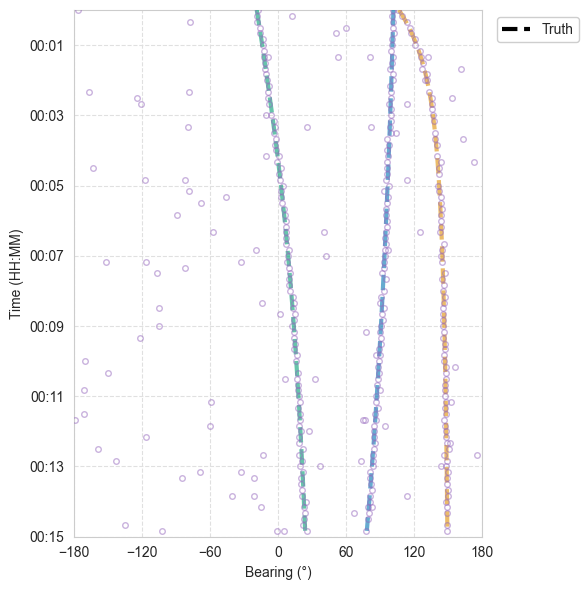

In [14]:
style_guide = {
    "figure": {
        "figsize": (6, 6),
        "font_size": 10
    }
}
plotter = BearingsPlotter(style_guide=style_guide, bearing_range_deg=(-180, 180))

plotter.plot(
    truths=relative_bearing_ground_truths,
    tracks=[],
    all_detections=ss_detections_for_plotter,
    timesteps=timesteps,
    mapping=[0],
    plot_uncertainty=True
)

In [15]:
# JPDA tracking on Stone Soup detections
# ============================================================================
# Models
# ============================================================================
transition_model = ConstantVelocity(0.0000001)
predictor = KalmanPredictor(transition_model)

measurement_model = LinearGaussian(
    ndim_state=2,
    mapping=[0],
    noise_covar=np.array([[np.deg2rad(1)**2]])
)
updater = WrappedBearingUpdater(measurement_model=measurement_model)

# ============================================================================
# JPDA for main tracking
# ============================================================================
FOV_RAD = np.deg2rad(180)
expected_false_alarms_per_scan = 3
clutter_spatial_density = expected_false_alarms_per_scan / FOV_RAD

jpda_hypothesiser = PDAHypothesiser(
    predictor=predictor,
    updater=updater,
    clutter_spatial_density=clutter_spatial_density,
    prob_detect=0.90
)
jpda_associator = JPDA(hypothesiser=jpda_hypothesiser)

# ============================================================================
# GNN for initiation (single-hypothesis, avoids MultipleHypothesis issue)
# ============================================================================
init_hypothesiser = DistanceHypothesiser(
    predictor=predictor,
    updater=updater,
    measure=Mahalanobis(),
    missed_distance=1.0
)
init_associator = GNNWith2DAssignment(init_hypothesiser)

# ============================================================================
# Track management
# ============================================================================
deleter = CovarianceBasedDeleter(covar_trace_thresh=0.1)

relative_bearing_ground_truth = relative_bearing_ground_truths[0]
initial_bearing = float(relative_bearing_ground_truth[0].state_vector[0]) + np.random.normal(0, np.deg2rad(2))
initial_bearing = wrap_to_pi(initial_bearing)

prior_state = GaussianState(
    np.array([[initial_bearing], [0.0]]),
    np.diag([np.deg2rad(5)**2, np.deg2rad(0.5)**2]),
    timestamp=SIM_PARAMS["start_time"]
)
wrap_state_bearing(prior_state)

initiator = MultiMeasurementInitiator(
    prior_state=prior_state,
    measurement_model=measurement_model,
    deleter=deleter,
    data_associator=init_associator, 
    updater=updater,
    min_points=4,
)

tracks, all_tracks = set(), set()

# ============================================================================
# Main loop
# ============================================================================
for timestamp, detections in stone_soup_detections:

    # Wrap detections
    for det in detections:
        det.state_vector[0, 0] = wrap_to_pi(float(det.state_vector[0, 0]))

    # JPDA association for existing tracks (convert detections list to set)
    detections_set = set(detections)
    associations = jpda_associator.associate(set(tracks), detections_set, timestamp)

    associated_detections = set()

    for track in list(tracks):
        track_hypotheses = associations[track]  # MultipleHypothesis

        posterior_states = []
        posterior_weights = []

        for hyp in track_hypotheses:
            if (hyp.measurement is None) or isinstance(hyp.measurement, MissedDetection):
                state = hyp.prediction
                wrap_state_bearing(state)
            else:
                state = updater.update(hyp)
                wrap_state_bearing(state)
                associated_detections.add(hyp.measurement)

            posterior_states.append(state)
            posterior_weights.append(float(hyp.probability))

        means = StateVectors([s.state_vector for s in posterior_states])
        covars = np.stack([s.covar for s in posterior_states], axis=2)
        weights = np.asarray(posterior_weights, dtype=float)
        if weights.sum() > 0:
            weights /= weights.sum()

        post_mean, post_covar = gm_reduce_single(means, covars, weights)
        post_mean = post_mean.copy()
        post_mean[0, 0] = wrap_to_pi(float(post_mean[0, 0]))

        track.append(GaussianStateUpdate(post_mean, post_covar, track_hypotheses, timestamp))

    # Delete and initiate (initiation uses GNN associator)
    tracks -= deleter.delete_tracks(tracks)
    tracks |= initiator.initiate(detections_set - associated_detections, timestamp)
    all_tracks |= tracks

# min_track_length = 4  # e.g., require 4 timesteps

# tracks = {t for t in tracks if len(t) >= min_track_length}
# all_tracks = {t for t in all_tracks if len(t) >= min_track_length}


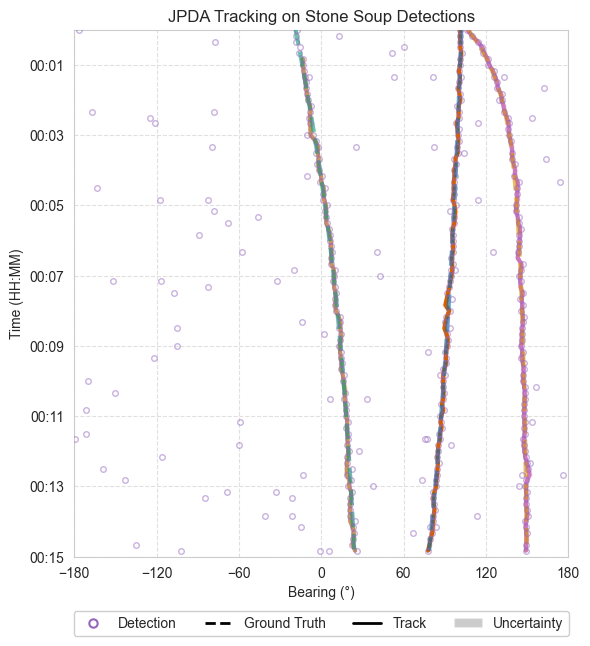

In [16]:
# Plot results using Stone Soup detections
style_guide = {
    "figure": {
        "figsize": (6, 6),
        "font_size": 10
    },
    "legend": {
        "display": False,  # Disable automatic legend
    },
}
plotter = BearingsPlotter(style_guide=style_guide, bearing_range_deg=(-180, 180))

ax = plotter.plot(
    truths=relative_bearing_ground_truths,
    tracks=tracks,
    all_detections=ss_detections_for_plotter,  # Use Stone Soup detections
    timesteps=timesteps,
    mapping=[0],
    plot_uncertainty=True
)

ax.set_title("JPDA Tracking on Stone Soup Detections")

# Create custom legend with items in a row
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='none', 
           markeredgecolor='#9467bd', markersize=6, markeredgewidth=1.5, 
           label='Detection', linestyle='None'),
    Line2D([0], [0], color='black', linestyle='--', linewidth=2, 
           label='Ground Truth'),
    Line2D([0], [0], color='black', linestyle='-', linewidth=2, 
           label='Track'),
    Patch(facecolor='black', alpha=0.2, label='Uncertainty'),
]

ax.legend(handles=legend_elements, loc='upper center', 
          bbox_to_anchor=(0.5, -0.09), ncol=4, 
          fancybox=True, shadow=False, frameon=True, framealpha=0.95)

In [17]:
# compare stone soup only tracks to nereus tracks
# using stone soup metrics